In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [13]:
sift = cv.SIFT_create()
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv.FlannBasedMatcher(index_params,search_params)

def find_obj(obj_img, target_img):
    kp1, des1 = sift.detectAndCompute(obj_img, None)
    kp2, des2 = sift.detectAndCompute(target_img, None)

    matches = flann.knnMatch(des1,des2,k=2)
    good = []
    for m,n in matches:
        if m.distance < 0.7*n.distance:
            good.append(m)

    if len(good) < 10:
        print("Not enough data")
        return
    else:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5)
        h, w = obj_img.shape[:2]
        bbox = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        dst = cv.perspectiveTransform(bbox, M)
        res = target_img.copy()
        cv.polylines(res,[np.int32(dst)],True,255,3, cv.LINE_AA)
        return res

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

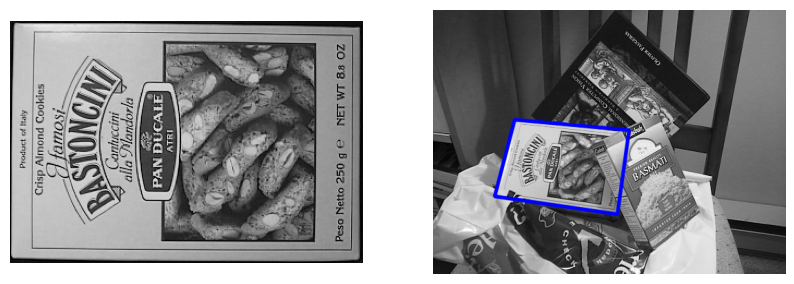

In [17]:
box_img = cv.imread('../../../class.vision/images/box.png')
box_in_scene_img = cv.imread('../../../class.vision/images/box_in_scene.png')

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(box_img[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(find_obj(box_img, box_in_scene_img)[...,::-1]); plt.title(""); plt.axis('off')

(np.float64(-0.5), np.float64(557.5), np.float64(404.5), np.float64(-0.5))

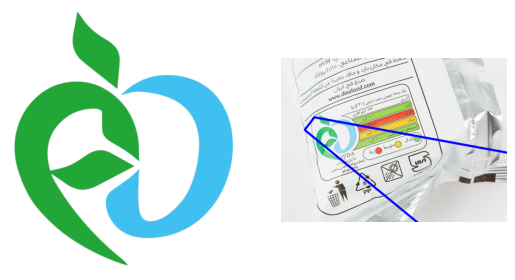

In [19]:
salamat_img = cv.imread('../../images/salamat.png')
chips_packet_img = cv.imread('../../images/chips_packet.jpg')

plt.subplot(121); plt.imshow(salamat_img[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(find_obj(salamat_img, chips_packet_img)[...,::-1]); plt.title(""); plt.axis('off')

(np.float64(-0.5), np.float64(955.5), np.float64(594.5), np.float64(-0.5))

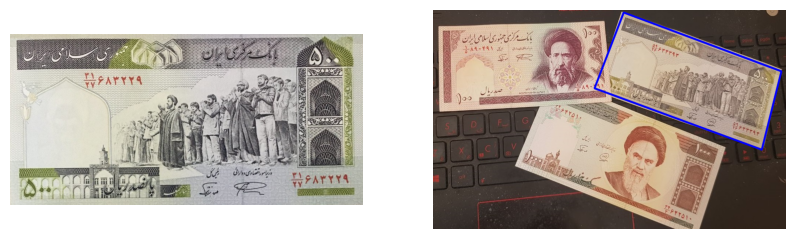

In [22]:
original_img1 = cv.imread('../../../class.vision/images/50tomani.jpg')
original_img2 = cv.imread('../../../class.vision/images/eskenas.jpg')

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(original_img1[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(find_obj(original_img1, original_img2)[...,::-1]); plt.title(""); plt.axis('off')